Visualize piecewise fits

In [16]:
from escripts import eplots
from escripts import edata
from escripts import eMCMC

In [5]:
epsilon = [-0.711, -0.719, -0.731, -0.741, -0.842, -0.833, -0.7, -0.422, -0.384]
epsilon_plus = [0.02, 0.02, 0.02, 0.03, 0.03, 0.03, 0.03, 0.04, 0.05, ]
epsilon_minus = [0.02, 0.02, 0.03, 0.03, 0.05, 0.04, 0.05, 0.07, 0.08]

In [6]:
sigma = [0.335, 0.38, 0.337, 0.322, 0.104, 0.129, 0.495, 1.079, 1.15]
sigma_plus = [0.06, 0.07, 0.06, 0.09, 0.12, 0.12, 0.07, 0.07, 0.07, ]
sigma_minus = [0.08, 0.195, 0.08, 0.08, 0, 0.01, 0.195, 0.11, 0.12, ]

In [7]:
eps_yerr = np.vstack([epsilon_minus, epsilon_plus])

In [8]:
sig_yerr = np.vstack((sigma_minus, sigma_plus))

In [9]:
zs = [4, 5, 6, 7, 8, 9, 10, 11, 12.5]

Text(0.5, 1.0, 'Base 4 parameters + piecewise $\\log \\epsilon_{\\star}$')

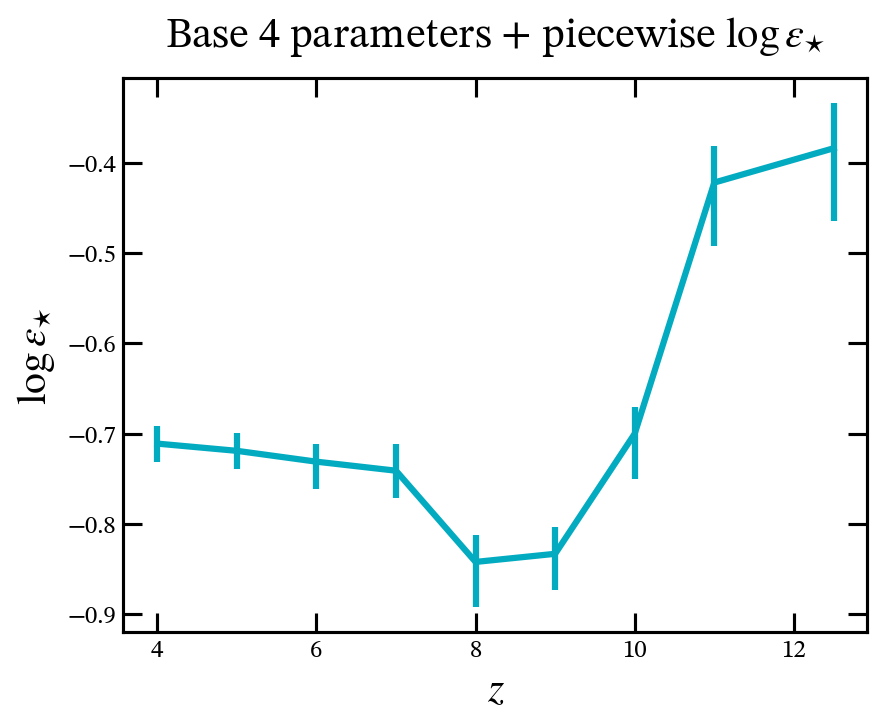

In [35]:
fig, ax = plt.subplots()
ax.errorbar(zs, epsilon, yerr = eps_yerr, color = eplots.turquoise)
ax.set_ylabel(r'$\log \epsilon_{\star}$')
ax.set_xlabel(r'$z$')
ax.set_title(r'Base 4 parameters + piecewise $\log \epsilon_{\star}$')

In [36]:
fig.savefig('/Users/eb35267/Desktop/code/figures/piecewise_epsilon.png')

Text(0.5, 1.0, 'Base 4 parameters + piecewise $\\sigma_{\\rm{UV}}$')

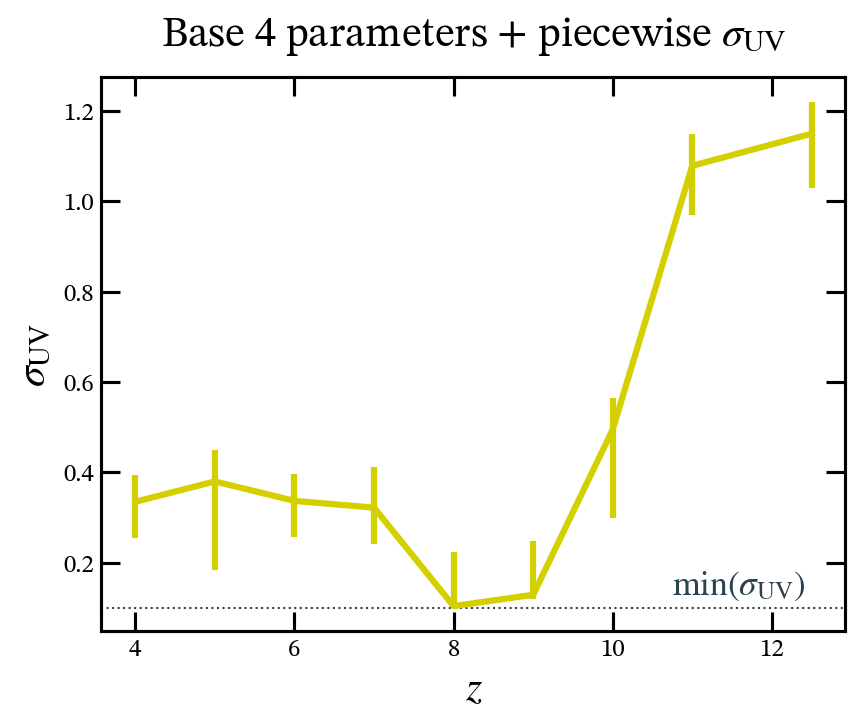

In [37]:
fig, ax = plt.subplots()
ax.errorbar(zs, sigma, yerr = sig_yerr, color = eplots.yellow)
ax.axhline(0.1, ls = 'dotted', lw = 1, color = eplots.navy)
ax.text(10.75, 0.13, r'$\min(\sigma_{\rm{UV}})$', color = eplots.navy)
ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$z$')
ax.set_title(r'Base 4 parameters + piecewise $\sigma_{\rm{UV}}$')

In [38]:
fig.savefig('/Users/eb35267/Desktop/code/figures/piecewise_sigma.png')

# UVLF

In [17]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
               '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [18]:
param_dict = eMCMC.build_param_data({'min_sig':{'value':0.1}})

In [19]:
my_UVLF = eMCMC.UVLF(sorted_data, param_dict, precisionboost = 2.9)

In [27]:
base_params = [0.549, -0.947, 12.059, -0.745, 0.3]

In [29]:
eps_fit = base_params.copy()
eps_fit[-2] = epsilon

In [31]:
sig_fit = base_params.copy()
sig_fit[-1] = sigma

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:242: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:242: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)


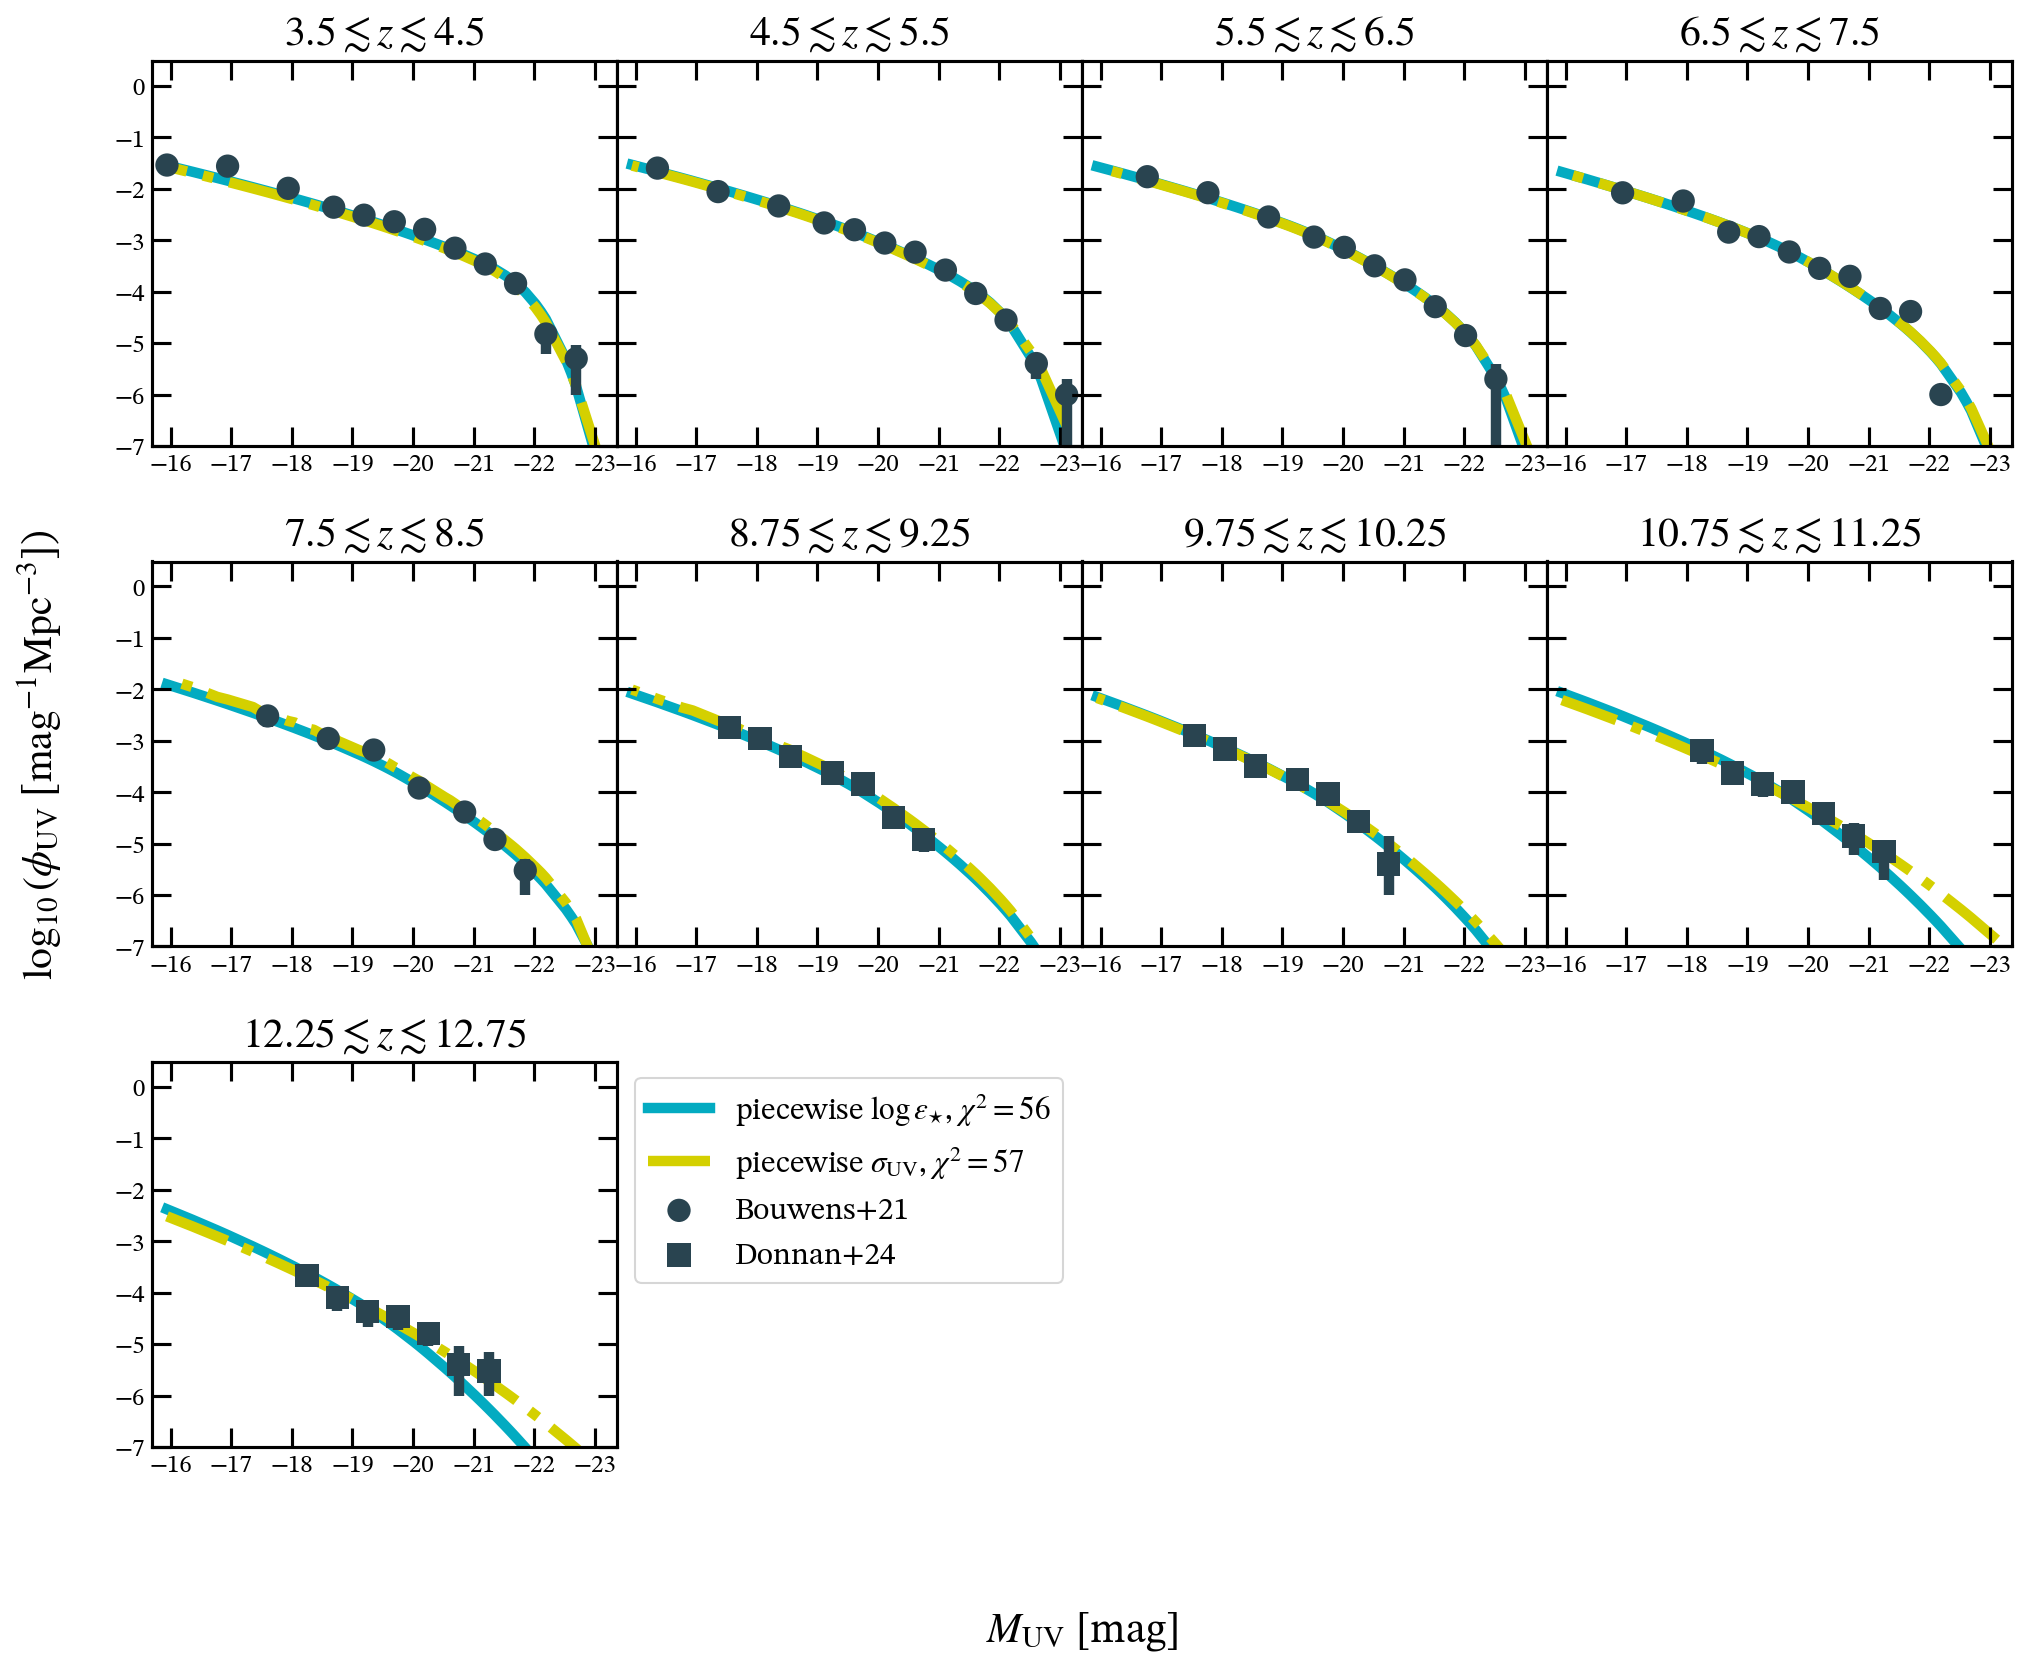

In [32]:
UVLF_fig = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain=False, comparison_fits = [eps_fit, sig_fit], 
                                    comparison_labels = [r'piecewise $\log \epsilon_{\star}$', r'piecewise $\sigma_{\rm{UV}}$'])

In [39]:
UVLF_fig.savefig('/Users/eb35267/Desktop/code/figures/piecewise_eps_vs_sig_comparison.png')

array([[2.91249165e-002, 3.06530462e-002, 3.22687501e-002, ...,
        9.35121660e-009, 8.32687591e-009, 7.41177911e-009],
       [1.98442188e-002, 2.08797845e-002, 2.19736026e-002, ...,
        4.28560789e-009, 3.80596243e-009, 3.37861725e-009],
       [1.35075135e-002, 1.42086413e-002, 1.49484879e-002, ...,
        1.93645186e-009, 1.71497152e-009, 1.51818767e-009],
       ...,
       [4.99873860e-019, 4.54968078e-019, 4.01528735e-019, ...,
        5.14820022e-131, 5.14820022e-131, 5.14820022e-131],
       [3.23269359e-019, 2.90202324e-019, 2.51913533e-019, ...,
        5.14820022e-131, 5.14820022e-131, 5.14820022e-131],
       [2.07620388e-019, 1.83549037e-019, 1.56428506e-019, ...,
        5.14820022e-131, 5.14820022e-131, 5.14820022e-131]])